<a href="https://colab.research.google.com/github/rparson4/MarsTharsisGlaciers/blob/main/MarsIceSublim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
# prompt: load MontesSimulationCompile.csv into pandas dataframe and loop through rows checking if column2 values are N, if so, plot them as green circles

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors # Import the colors module

In [ ]:
# Constants
Hsubl = 5.1058 * 10**4 #J mol− 1 Latent Heat of sublimation
R = 8.31 #J/mol Ideal Gas Const
D = 5 * 10**-4 #m2 s− 1 (incorrect in Parsons et al 2020 ... no negative!) is the water vapor diffusivity through the lag which was measured for the JSC-1 Mars regolith analog (Hudson et al. 2007) at temperatures between 200 and 263 K
MH2O = 0.018 #kg/mol Molar mass of water
rho = 910. #kg m− 3 # Ice density
pt = 611. #Pa and
Tt = 273. #K give the triple point of water

In [ ]:
5.1058 * 10**4 / (8.31)

6144.16365824308

In [ ]:
# (Potential) Variables
RH = 0.01 # Relative Humidity (fraction)
T = np.linspace(180,225,400) # Sfc Temperature (K)
L = np.logspace(-2,1,400) # Lag thickness (m)

In [ ]:
# Sublimation Calc
X, Y = np.meshgrid(T, L)
psat = pt * np.exp(-Hsubl/R*(1./X - 1./Tt))
psatmod = pt * np.exp(6293.*(1./273. - 1./X)-0.555*np.log(X/273.))
E = D*MH2O*psat / (Y*R*X*rho) * (1. - RH) * np.pi*1e7 # Seconds -> yrs
Emod = D*MH2O*psatmod / (Y*R*X*rho) * (1. - RH) * np.pi*1e7 # Seconds -> yrs

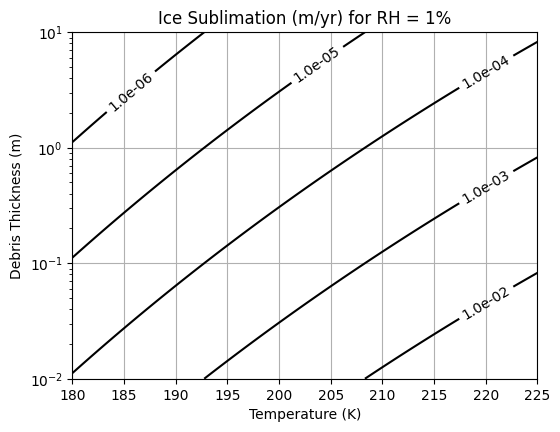

In [ ]:
# Create Contour Plot
import matplotlib.colors as colors # Import the colors module
import matplotlib.ticker as mticker

plt.figure(figsize=(6, 4.5))
contour = plt.contour(X, Y, E, levels=np.logspace(-10,-1,10),colors='black') #, cmap='viridis')
plt.yscale('log')
# plt.colorbar(contour, label='Sublimation (m/yr)', norm=colors.LogNorm())

# Use a lambda function for formatting labels in scientific notation
# The format string '%.1e' formats the number to one decimal place in scientific notation
plt.clabel(contour, inline=1, fontsize=10, fmt=lambda x: f'{x:.1e}')
tstr = 'Ice Sublimation (m/yr) for RH = ' + str(int(RH*100)) + '%'
plt.title(tstr)
plt.xlabel('Temperature (K)')
plt.ylabel('Debris Thickness (m)')
plt.grid(True)
plt.show()

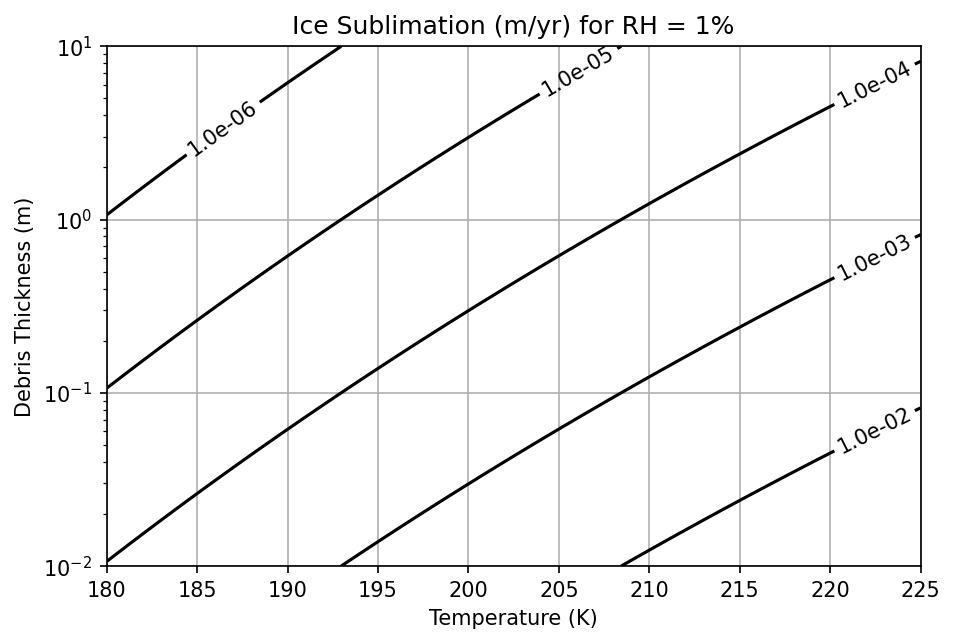

In [ ]:
# Create Contour Plot
import matplotlib.colors as colors # Import the colors module
import matplotlib.ticker as mticker

plt.figure(figsize=(7, 4.5),dpi=150)
contour = plt.contour(X, Y, Emod, levels=np.logspace(-10,-1,10),colors='black') #, cmap='viridis')
plt.yscale('log')
# plt.colorbar(contour, label='Sublimation (m/yr)', norm=colors.LogNorm())

# Use a lambda function for formatting labels in scientific notation
# The format string '%.1e' formats the number to one decimal place in scientific notation
plt.clabel(contour, inline=1, fontsize=10, fmt=lambda x: f'{x:.1e}')
tstr = 'Ice Sublimation (m/yr) for RH = ' + str(int(RH*100)) + '%'
plt.title(tstr)
plt.xlabel('Temperature (K)')
plt.ylabel('Debris Thickness (m)')
plt.grid(True)
plt.show()

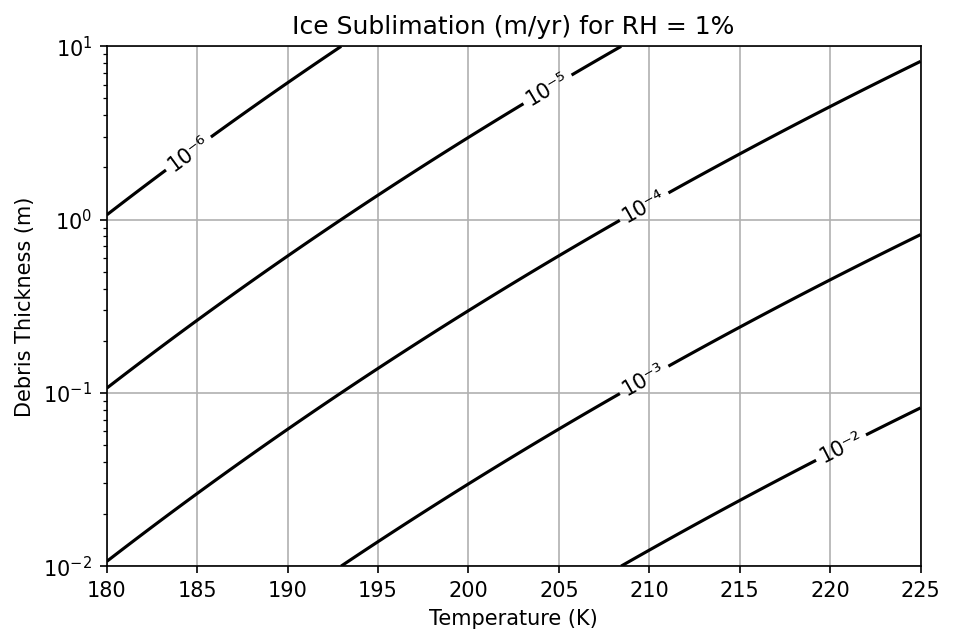

In [ ]:
import matplotlib.colors as colors
import matplotlib.ticker as mticker

def to_superscript(n):
    superscript_map = {
        '0': '⁰', '1': '¹', '2': '²', '3': '³', '4': '⁴',
        '5': '⁵', '6': '⁶', '7': '⁷', '8': '⁸', '9': '⁹',
        '-': '⁻'
    }
    s = str(int(n))
    return ''.join(superscript_map.get(char, char) for char in s)

plt.figure(figsize=(7, 4.5),dpi=150)
contour = plt.contour(X, Y, Emod, levels=np.logspace(-10,-1,10),colors='black')
plt.yscale('log')

# Use a lambda function for formatting labels as 10 with superscript exponent
plt.clabel(contour, inline=1, fontsize=10, fmt=lambda x: f'10{to_superscript(np.log10(x))}')
tstr = 'Ice Sublimation (m/yr) for RH = ' + str(int(RH*100)) + '%'
plt.title(tstr)
plt.xlabel('Temperature (K)')
plt.ylabel('Debris Thickness (m)')
plt.grid(True)
plt.show()